# Word Similarity with BERT

In Lucy Li's [paper about language variation across Reddit communities](https://arxiv.org/abs/2102.06820), she used two methods for determining the community-specific meanings of certain words: comparing the similarity of their BERT embeddings within commmunities, and comparing their potential BERT-dervied substitutes within communities. In the case of the former, the underlying method is a measure of cosine similarity, which we've already employed with respect to word embeddings, and which is what this notebook will explore. Here we'll take a break from our restaurant review corpus and use a collection of 16th-20th century English language poems.

## Data and model
Our poems were scraped from [Public-Domain-Poetry.com](http://public-domain-poetry.com/) by University of Washington professor Melanie Walsh. As for our model, we'll be using the [DistilBert model](https://huggingface.co/transformers/model_doc/distilbert.html) via HuggingFace. DistilBert is a smaller — yet still powerful! — version of BERT. By using the rich representations of words that BERT produces, we will then explore the multivalent meanings of particular words in context and over time.

## Overview: Word similarity
Just as Lucy asked whether r/Fitness and r/CasualUK used the word "lift" in different ways, we can ask whether 16th-century and 20th-century poets use the word "science" in different ways. Or the word "nature." Or the word "machine." (This single question was actually the source of [a multiyear project at the Turing Institute](https://livingwithmachines.ac.uk/), which has resulted in many interesting papers you might want to read). In any case, we'll just use cosine similiarity to compare the various embeddings to each other.

## **Import necessary Python libraries and modules**

First import the DistilBertModel and DistilBertTokenizerFast from Hugging Face, using their `transformers` library. We will also import a handful of other Python libraries and modules.

In [ ]:
# For BERT
from transformers import DistilBertTokenizerFast, DistilBertModel

# For data manipulation and analysis
import pandas as pd
pd.options.display.max_colwidth = 200
import numpy as np
from sklearn.decomposition import PCA

# For interactive data visualization
import altair as alt

## **Load text dataset**

Our dataset contains around ~30 thousand poems scraped from  http://public-domain-poetry.com/. This website hosts a curated collection of poems that have fallen out of copyright, which makes them easier for us to share on the web.
You can find the data in Melanie Walsh's [GitHub repository](https://github.com/melaniewalsh/BERT-4-Humanists/blob/main/data/public-domain-poetry.csv).

We don't have granular date information about when each poem was published, but we do know the birth dates of most of our authors, which we've used to loosely categorize the poems by time period. The poems in our data range from the Middle Ages to the 20th Century, but most come from the 19th Century. The data features both well-known authors — William Wordsworth, Emily Elizabeth Dickinson, Paul Laurence Dunbar, Walt Whitman, Shakespeare — as well as less well-known authors.

In what follows, we'll use `pandas` to read in a CSV file of poems from Melanie's GitHub.

In [ ]:
url = "https://raw.githubusercontent.com/melaniewalsh/BERT-4-Humanists/main/data/public-domain-poetry.csv"

poetry_df = pd.read_csv(url, encoding='utf-8')
# Show 5 random rows
poetry_df.sample(5)

,author,title,text,lifespan,birth_year,death_year,link,period
433,Alexander Pope,Phyrne,"Phryne had talents for mankind,\r\nOpen she was, and unconfin'd,\r\nLike some free port of trade:\r\nMerchants unloaded here their freight,\r\nAnd Agents from each foreign state,\r\nHere first the...",21 May 1688-30 May 1744,1688.0,1744.0,http://public-domain-poetry.com/alexander-pope/phyrne-1655,18th Century
10172,Henry Wadsworth Longfellow,Curfew,"I.\n\r\nSolemnly, mournfully,\r\nDealing its dole,\r\nThe Curfew Bell\r\nIs beginning to toll.\n\r\nCover the embers,\r\nAnd put out the light;\r\nToil comes with the morning,\r\nAnd rest with the...","February 27, 1807-March 24, 1882",1807.0,1882.0,http://public-domain-poetry.com/henry-wadsworth-longfellow/curfew-24161,19th Century
5144,Edgar Lee Masters,Felix Schmidt,"It was only a little house of two rooms - \r\nAlmost like a child's play-house - \r\nWith scarce five acres of ground around it;\r\nAnd I had so many children to feed\r\nAnd school and clothe, and...","August 23, 1868, -March 5, 1950",1868.0,1950.0,http://public-domain-poetry.com/edgar-lee-masters/felix-schmidt-37518,19th Century
10760,Ivan Sergeyevich Turgenev,The Beggar,"I was walking along the street ... I was stopped by a decrepit old beggar.\n\r\nBloodshot, tearful eyes, blue lips, coarse rags, festering wounds.... Oh, how hideously poverty had eaten into this ...",November 9 1818-September 3 1883,1818.0,1883.0,http://public-domain-poetry.com/ivan-sergeyevich-turgenev/beggar-34846,19th Century
13793,John Wilmot,My Dear Mistress Has A Heart,"My dear mistress has a heart\r\nSoft as those kind looks she gave me,\r\nWhen with love's resistless art,\r\nAnd her eyes, she did enslave me;\r\nBut her constancy's so weak,\r\nShe's so wild and ...","April 1, 1647 - July 26, 1680",1647.0,1680.0,http://public-domain-poetry.com/john-wilmot/my-dear-mistress-has-a-heart-2814,16th-17th Centuries (Early Modern)


Let's check to see how many poems are in this dataset:

In [ ]:
len(poetry_df)

31080

Let's check to see which authors show up the most in this dataset to get a sense of its contours:

In [ ]:
poetry_df['author'].value_counts()[:20]

,count
author,
Robert Herrick,1464
Madison Julius Cawein,1345
William Wordsworth,963
Thomas Moore,853
Thomas Hardy,655
Rudyard Kipling,638
Robert Burns,499
John Greenleaf Whittier,481
Algernon Charles Swinburne,461


Let's also check to see what time periods show up the most in this dataset to get a sense of its contours:

<Axes: >

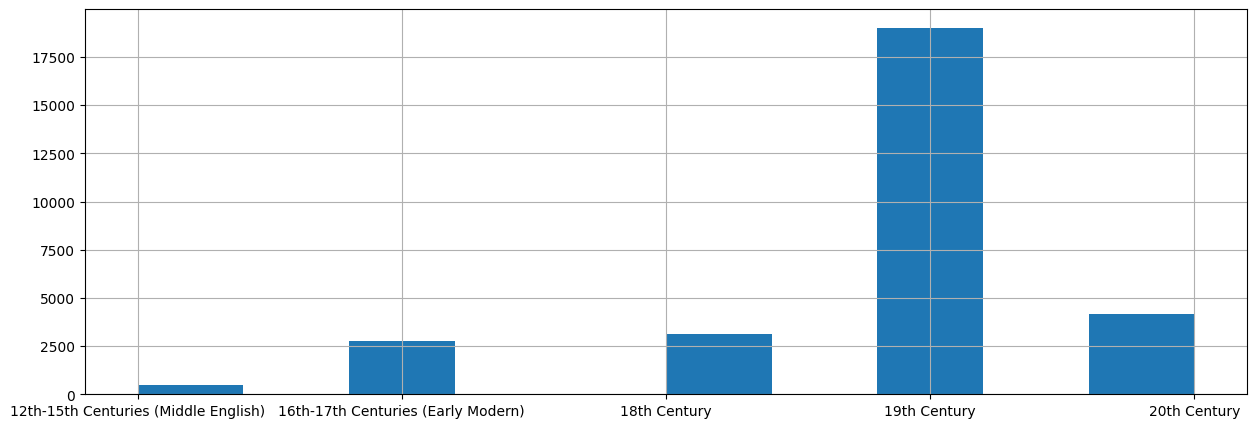

In [ ]:
# Sort values, then create a histogram, and define the size of the figure
poetry_df['period'].sort_values().hist(figsize=(15, 5))

## **Subsample text dataset**

Create a subsample, segmented by century.


Though we wish we could analyze all the poems in this data, non-Pro Colab tends to crash if we try to use more than 4-5,000 poems —  even with DistilBert, the smaller version of BERT.

So for our purposes today, to reduce the number of poems into a managable amount, we will take a random sample of 1,000 poems from four different time periods: the 20th Century, 19th Century, 18th Century, and the Early Modern period.

In [ ]:
# Filter the DataFrame for only a given time period, then randomly sample 1000 rows
nineteenth_sample = poetry_df[poetry_df['period'] == '19th Century'].sample(1000)
twentieth_sample = poetry_df[poetry_df['period'] == '20th Century'].sample(1000)
eighteenth_sample = poetry_df[poetry_df['period'] == '18th Century'].sample(1000)
sixteenth_sample = poetry_df[poetry_df['period'] == '16th-17th Centuries (Early Modern)'].sample(1000)

In [ ]:
# Merge these random samples into a new DataFrame
poetry_df = pd.concat([sixteenth_sample, eighteenth_sample, twentieth_sample, nineteenth_sample])

In [ ]:
poetry_df['period'].value_counts()

,count
period,
16th-17th Centuries (Early Modern),1000
18th Century,1000
20th Century,1000
19th Century,1000


Finally, let's make a list of poems from our Pandas DataFrame.

In [ ]:
# Make a list of the poem texts and check how many we have
poetry_texts = poetry_df['text'].tolist()

len(poetry_texts)


4000

Examine a poem in your dataset. Everyone's will be different, because we've each individually created a random sample from a larger dataset.


In [ ]:
len(poetry_texts)

4000

In [ ]:
print(poetry_texts[0])

Charles and I say it wond'ring thou must know
That I who once assum'd a scornful air,
And scoff'd at love, am fallen in his snare
(Full many an upright man has fallen so)
Yet think me not thus dazzled by the flow
Of golden locks, or damask cheek; more rare
The heart-felt beauties of my foreign fair;
A mien majestic, with dark brows, that show
The tranquil lustre of a lofty mind;
Words exquisite, of idioms more than one,
And song, whose fascinating pow'r might bind,
And from her sphere draw down the lab'ring Moon,
With such fire-darting eyes, that should I fill
My ears with wax, she would enchant me still.


## **Tokenize our poems for BERT**

The tokenization step is the first of two steps I want us to move through slowly, since it's the first glimpse we have into the current LLM training pipeline, and we're going to continue to build upon it in our class project.

We did a version of this last class before training our word2vec model as well, when we split our reviews into sentences, and then sentences into words.

Here, we'll tokenize the poems with the `tokenizer()` from HuggingFace's `DistilBertTokenizerFast`. This is what the `tokenizer()` will do:

1. Truncate the texts if they're more than 512 tokens or pad them if they're fewer than 512 tokens. If a word is not in BERT's vocabulary, it will be broken up into smaller "word pieces," demarcated by a `##`.

2. Add in special tokens to help BERT:
    - [CLS] — Start token of every document
    - [SEP] — Separator between each sentence
    - [PAD] — Padding at the end of the document as many times as necessary, up to 512 tokens
    - &#35;&#35; — Start of a "word piece"

Here we will use `DistilBertTokenizerFast` from the HuggingFace library, which will help us transform and encode the texts so they can be used with BERT.

In [ ]:
# from transformers import DistilBertTokenizerFast

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

The `tokenizer()` will break word tokens into word pieces, truncate to 512 tokens, and add padding and special BERT tokens.

In [ ]:
tokenized_poems = tokenizer(poetry_texts, truncation=True, padding=True, return_tensors="pt")

Let's examine the first tokenized poem. We can see that the special BERT tokens have been inserted where necessary.

In [ ]:
import textwrap

print(textwrap.fill(poetry_texts[0], width=80))

print("\nThe same poem, tokenized (raw form):\n")

tokens = tokenized_poems[0].tokens
tokens = [t for t in tokens if t != tokenizer.pad_token]   # drop padding
print(textwrap.fill(' | '.join(tokens), width=80))

# print out the attention mask
print("\nThe same poem, attention mask:\n")
print(textwrap.fill(str(tokenized_poems[0].attention_mask), width=80))

Charles and I say it wond'ring thou must know  That I who once assum'd a
scornful air,  And scoff'd at love, am fallen in his snare  (Full many an
upright man has fallen so)  Yet think me not thus dazzled by the flow  Of golden
locks, or damask cheek; more rare  The heart-felt beauties of my foreign fair;
A mien majestic, with dark brows, that show  The tranquil lustre of a lofty
mind;  Words exquisite, of idioms more than one,  And song, whose fascinating
pow'r might bind,  And from her sphere draw down the lab'ring Moon,  With such
fire-darting eyes, that should I fill  My ears with wax, she would enchant me
still.

The same poem, tokenized (raw form):

[CLS] | charles | and | i | say | it | won | ##d | ' | ring | thou | must | know
| that | i | who | once | ass | ##um | ' | d | a | sc | ##orn | ##ful | air | ,
| and | sc | ##off | ' | d | at | love | , | am | fallen | in | his | s | ##nare
| ( | full | many | an | upright | man | has | fallen | so | ) | yet | think |
me | not | thus

**Who can interpret this for us? What are the things in square brackets? Why are there hashtags? And why does the attention mask have all those zeroes?!**


In [ ]:
# Scratch space for working through the question above


## **Load the pre-trained BERT model**

Conceptually, this is where our process fully diverges from our restaurant reviews embedding model. We're not going to train a new model from scratch. Instead, we're going to use a pretrained BERT model to read our poems and hand back a vector for every token.

We begin by loading the model. To speed things up we will use a GPU where one is available.

The command `.to("cuda")` moves data from a regular CPU to a GPU, and also tells PyTorch (the library which allows us to manipulate all these tensors) to use the CUDA platform, a mid-layer parallel computing platform that makes everything run more efficiently.

Rather than hard-coding this, the cell below sets a `device` variable: it uses the GPU if Colab has given you one, and falls back to the CPU if not. Everything downstream refers to `device`, so this is the only place you would need to change it. **On the CPU this notebook will still work, but the embedding loop will be considerably slower** — set your runtime to GPU if you can (Runtime → Change runtime type → GPU).



In [ ]:
import torch
from transformers import DistilBertModel

In [ ]:
# Use a GPU if one is available, and fall back to the CPU if not.
# Everything below refers to `device`, so this is the only cell you need to change.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = DistilBertModel.from_pretrained('distilbert-base-uncased').to(device)


Using device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## **Get BERT embeddings for each poem in our dataset**

To get embeddings for all the words in our datset, we will use a basic `for` loop.

This is the second step I want to move slowly through.

The process is as follows: for each poem in our list `poetry_texts`, we will tokenize the poem, and we will extract the vocabulary word ID for each word/token in the poem (to use for later reference). Then we will run the tokenized poem through the BERT model, which does a couple of things beneath the surface, as explined in our slides.

The end result is that we extract the contextual embedding vectors for each word/token in the poem.

### Clarification: one thing we are *not* doing is training!

It is worth being clear about what happens in the cell below, because it is easy to assume that running data through a model must be training it. It isn't.

`DistilBertModel.from_pretrained(...)` **downloaded weights that were already trained** — by someone else, on Wikipedia and BookCorpus, at their expense. What we do here is a single **forward pass**: text goes in, vectors come out, and nothing about the model changes.

Keeping the tensors straight helps:

| | what it is | does it change here? |
|---|---|---|
| **Inputs** | what the tokenizer produced, `[1, seq_len]` | new for each poem |
| **Parameters** | the model's ~66 million weights | **no** — read, never written |
| **Outputs** | `last_hidden_state`, `[1, seq_len, 768]` | new for each poem |

OK. Here we go.

In [ ]:
# List of vocabulary word IDs for all the words in each document (aka each poem)
doc_word_ids = []
# List of word vectors for all the words in each document (aka each poem)
doc_word_vectors = []

# Below we will slice our poem to ignore the first (0th) and last (-1) special BERT tokens
start_of_words = 1
end_of_words = -1

# Below we will index the 0th or first document, which will be the only document, since we're analzying one poem at a time
first_document = 0

for i, poem in enumerate(poetry_texts):

    # Here we tokenize each poem with the DistilBERT Tokenizer
    inputs = tokenizer(poem, return_tensors="pt", truncation=True, padding=True)

    # Here we extract the vocabulary word ids for all the words in the poem (the first or 0th document, since we only have one document)
    # We ignore the first and last special BERT tokens
    # We also convert from a Pytorch tensor to a numpy array
    doc_word_ids.append(inputs.input_ids[first_document].numpy()[start_of_words:end_of_words])

    # Here we send the tokenized poem to the same device as the model
    # The model is already there, but this poem isn't, so we send it across
    inputs.to(device)
    # Here we run the tokenized poem through the DistilBERT model.
    # Note that we are NOT training the model here. We are only running text through
    # it and reading the vectors back out, so PyTorch doesn't need to keep track of
    # the gradients it would use to update weights. torch.no_grad() switches that
    # bookkeeping off, which saves a substantial amount of GPU memory.
    with torch.no_grad():
        outputs = model(**inputs)

    # We take every element from the first or 0th document, from the 2nd to the 2nd to last position
    # Grabbing the last layer is one way of getting token vectors. There are different ways to get vectors with different pros and cons
    # (.detach() is redundant now that we are inside torch.no_grad(), but it is harmless and it makes the same point explicitly)
    doc_word_vectors.append(outputs.last_hidden_state[first_document,start_of_words:end_of_words,:].detach().cpu().numpy())


Confirm that we have the same number of documents for both the tokens and the vectors:

In [ ]:
len(doc_word_ids), len(doc_word_vectors)

(4000, 4000)

## **Concatenate all word IDs/vectors for all documents**

Each element of these lists contains all the tokens/vectors for one document. But we want to concatenate them into two giant collections for ease of use.

Now that we've got our word IDs and our vectors, we can move on.


In [ ]:
all_word_ids = np.concatenate(doc_word_ids)
all_word_vectors = np.concatenate(doc_word_vectors, axis=0)

## **Set Up Cosine Similarity Calculations**


Here's where we start to set up the cosine similarity calculations that we're going to do down below. Because cosine similarity measures the angle between vectors but ignores their length, we can speed this computation up by setting all the poem vectors to have length 1.0.


In [ ]:
# Calculating the length of each vector (Pythagorean theorem)
row_norms = np.sqrt(np.sum(all_word_vectors ** 2, axis=1))
# Dividing every vector by its length
all_word_vectors /= row_norms[:,np.newaxis]

Now that we've normalized our vectors so that each has a length of 1, we can calculate the cosine similiarity between one vector and any other (or set of others) by taking the dot product of the two vectors. Here's a function we can write to do that:


In [ ]:
def get_nearest(query_vector, n=20):
  cosines = all_word_vectors.dot(query_vector)
  ordering = np.flip(np.argsort(cosines))

  return ordering[:n]

But, to make any results legible to humans, we need to be able to reattach these vectors to the words and contexts that they represent. Here are a bunch of functions that can help us do that:

## **Helpful functions**

Just execute these next few cells so we have some helper functions to use.

**Find all word positions in a collection**


This function uses the array `all_word_ids` to find all the places, or *positions*, in the collection where a word appears.

We'll do this with the `tokenizer.vocab` attribute, finding the word's vocab ID in BERT and then checking to see where/how many times this ID occurs in `all_word_ids`.

In [ ]:
def get_word_positions(words):

  """This function accepts a list of words, rather than a single word"""

  # Get word/vocabulary ID from BERT for each word
  word_ids = [tokenizer.vocab[word] for word in words]

  # Find all the positions where the words occur in the collection
  word_positions = np.where(np.isin(all_word_ids, word_ids))[0]

  return word_positions

For example, we can check to see all the places where the word "bank" appears in the collection.

In [ ]:
get_word_positions(["bank"])

array([ 72773,  82251,  82591,  92888, 116384, 134963, 144561, 165508,
       168001, 203086, 203088, 288574, 352442, 371937, 406194, 430137,
       449620, 459300, 481739, 561500, 561790, 579416, 607000, 656229,
       660327, 666877, 667066, 677628, 707920, 711552, 722978, 759520,
       768313, 768384, 793346, 798213, 813196, 829184, 832037, 842787,
       842907, 842947, 877801, 905383, 907449, 920168, 923713, 982986])

**Use get_word_positions to find word from word position**

The above function allow us to determine all the positions where the word "bank" appears in the collection. But it would be more helpful to us as humans to know the actual words that appear in context around it. To find these context words, we have to convert position IDs back into words, like so:

In [ ]:
# Here we create an array so that we can go backwards from numeric token IDs to words
word_lookup = np.empty(tokenizer.vocab_size, dtype="O")

for word, index in tokenizer.vocab.items():
    word_lookup[index] = word

Now we can use `word_lookup` to find a word based on its position in the collection. Let's first see what the output of a basic lookup operation looks like, printing the three words that come before it and the three words that come after.

In [ ]:
word_positions = get_word_positions(["bank"])

for word_position in word_positions:

  # Slice 3 words before "bank"
  start_pos = word_position - 3
  # Slice 3 words after "bank"
  end_pos = word_position + 4

  context_words = word_lookup[all_word_ids[start_pos:end_pos]]
  # Join the words together
  context_words = ' '.join(context_words)
  print(word_position, context_words)

72773 ##tty * * bank , the which
82251 sent , the bank ##es to weep
82591 here by this bank of lil ##ies
92888 a sunni ##e bank ##e outstretched lay
116384 self ##e a bank ##rou ##t know
134963 by , this bank ##e with roses
144561 . on a bank , beside a
165508 sober stream , bank ' d all
168001 vp ##pon a bank with roses set
203086 , shooting from bank to bank ,
203088 from bank to bank , now in
288574 from the snowy bank the foot ##marks
352442 , and the bank where they grew
371937 ! from what bank came those live
406194 on the green bank of clear al
430137 lily by the bank , the pri
449620 to the river bank and fee ##ble
459300 change and the bank - note boat
481739 . . the bank default ##er lee
561500 shrine is a bank of so ##d
561790 shrine is a bank of so ##d
579416 and the turf bank wears with glee
607000 on the river bank where i came
656229 river ' s bank , come in
660327 in the county bank , and henry
666877 ! upon a bank , ease ##less
667066 clouds above that bank , it strain

Now that we've tested out this approach, let's make some functions that will help us get the context words around a certain word position for whatever size window (certain number of words before and after) that we want.

The first function `get_context()` will simply return the tokens without cleaning them, and the second function `get_context_clean()` will return the tokens in a more readable fashion. (Note the return of regex!)

In [ ]:
def get_context(word_id, window_size=10):

  """Simply get the tokens that occur before and after word position"""

  start_pos = max(0, word_id - window_size) # The token where we will start the context view
  end_pos = min(word_id + window_size + 1, len(all_word_ids)) # The token where we will end the context view

  # Make a list called tokens and use word_lookup to get the words for given token IDs from starting position up to the keyword
  tokens = [word_lookup[word] for word in all_word_ids[start_pos:end_pos] ]

  context_words = " ".join(tokens)

  return context_words

In [ ]:
import re

def get_context_clean(word_id, window_size=10):

  """Get the tokens that occur before and after word position AND make them more readable"""

  keyword = word_lookup[all_word_ids[word_id]]
  start_pos = max(0, word_id - window_size) # The token where we will start the context view
  end_pos = min(word_id + window_size + 1, len(all_word_ids)) # The token where we will end the context view

  # Make a list called tokens and use word_lookup to get the words for given token IDs from starting position up to the keyword
  tokens = [word_lookup[word] for word in all_word_ids[start_pos:end_pos] ]

  # Make wordpieces slightly more readable
  # This is probably not the most efficient way to clean and correct for weird spacing
  context_words = " ".join(tokens)
  context_words = re.sub(r'\s+([##])', r'\1', context_words)
  context_words = re.sub(r'##', r'', context_words)
  context_words = re.sub(r'\s+\'s', r'\'s', context_words)
  context_words = re.sub(r'\s+\'d', r'\'d', context_words)
  context_words = re.sub(r'\s+\'er', r'\'er', context_words)
  context_words = re.sub(r'\s+([-,:?.!;])', r'\1', context_words)
  context_words = re.sub(r'([-\'\"])\s+', r'\1', context_words)
  context_words = re.sub(r'\s+\'s', r'\'s', context_words)
  context_words = re.sub(r'\s+\'d', r'\'d', context_words)

  # Bold the keyword by putting asterisks around it
  if keyword in context_words:
    context_words = re.sub(f"\\b{keyword}\\b", f"**{keyword}**", context_words)
    context_words = re.sub(f"\\b({keyword}[esdtrlying]+)\\b", fr"**\\1**", context_words)

  return context_words

## **Examining most similar vectors**

At long last, we're ready to perform our similarity comparison. First we need to decide which particular instance of "bank" we want to examine. Let's print out some instances of "bank" in our poetry corpus to see if one seems interesting to us.



In [ ]:
# load some libraries for displaying text nicely
from IPython.display import Markdown, display

def print_md(string):
    display(Markdown(string))

In [ ]:
# print out instances of "bank" in the corpus
word_positions = get_word_positions(['bank'])

for word_position in word_positions:

  print_md(f"{word_position}: {get_context_clean(word_position)} <br>")

72773: silver streaming themmes; whose rutty * * **bank**, the which his river hemmes, was pay <br>

82251: threw, such sounds yet forth it sent, the **\1** to weepe that drue, as down <br>

82591: illis, rest but a while here by this **bank** of lilies; and lend a gentle ear to <br>

92888: shore of muddie nile, upon a sunnie **\1** outstretched lay, in monstrous length, a might <br>

116384: , and by iust counts my selfe a bankrout know of all those goods which heau <br>

...

905383: is perfect o waly, waly up the **bank**, and waly, waly down the bra <br>

907449: savored much of heaven. close by the **bank**, in shady nooks, the waxen <br>

920168: enough, now we 'll take it to the **bank** and see what we can find, give the dish <br>

923713: his trade, an 'muckle i 'the **bank** had laid, he wadna spare o 't <br>

982986: their memory-hallowed acres. their gardens, **\1** with roses and with lilies-those sweet <br>

Now we can pick any of these keyword positions to compare to.

In [ ]:
keyword_position = 877801 # can be replaced with any of the above

And at long last, display the most similar vectors

In [ ]:
contexts = [get_context_clean(token_id) for token_id in get_nearest(all_word_vectors[keyword_position,:])]

for context in contexts:
  print_md(context)

are bred from the slime of the nile-**bank**, shapeless, a terror to see; and

young morning; the reapers are asleep; the river **bank** is lonely: come away! the early murmurs of

, 'mid the circling wood, on the green **bank** of clear alb [ = u ] nea

ccasins. we crawled down to the river **bank** and feeble folk were we, that julie claire

took a view of my favourite field, and the **bank** where they grew; and now in the grass behold

...

silver streaming themmes; whose rutty * * **bank**, the which his river hemmes, was pay

a purple opulence. iii. along the **bank** in a wild procession of gold and sapphire the blossoms

t. iii. now blooms the lily by the **bank**, the primrose down the brae;

man; thou chief, poetic spirit, from the **banks** of avon, whence thy holy fingers cull

belliferous flowers, and the yellow clay of its **bank**, the barge\'s brown sails that are fur

## **Reduce word vectors via PCA and plot them**

We don't need to just *read* examples of similar usages of "bank" in the collection, we can also visualize them.

But to do so, we need to perform some dimensionality reduction. We'll use PCA again.

In [ ]:
from sklearn.decomposition import PCA

word_positions = get_word_positions(["bank"])

pca = PCA(n_components=2)

pca.fit(all_word_vectors[word_positions,:].T)

PCA(n_components=2)

Let's now make a list of all of the context views for our keyword so that we can associate them with their PCA score:

In [ ]:
word_positions = get_word_positions(["bank"])

keyword_contexts = []
keyword_contexts_tokens = []

for position in word_positions:

  keyword_contexts.append(get_context_clean(position))
  keyword_contexts_tokens.append(get_context(position))

Then, for convenience, we will put these PCA results into a Pandas DataFrame, which will use to generate an interactive plot.

In [ ]:
df = pd.DataFrame({"x": pca.components_[0,:], "y": pca.components_[1,:],
                   "context": keyword_contexts, "tokens": keyword_contexts_tokens})
df.head()

,x,y,context,tokens
0,0.146973,0.064636,"silver streaming themmes; whose rutty * * **bank**, the which his river hemmes, was pay","silver streaming them ##mes ; whose ru ##tty * * bank , the which his river hem ##mes , was pay"
1,0.132484,0.305686,"threw, such sounds yet forth it sent, the **\1** to weepe that drue, as down","threw , such sounds yet forth it sent , the bank ##es to weep ##e that dr ##ue , as down"
2,0.148149,0.095229,"illis, rest but a while here by this **bank** of lilies; and lend a gentle ear to","##ill ##is , rest but a while here by this bank of lil ##ies ; and lend a gentle ear to"
3,0.140911,0.239201,"shore of muddie nile, upon a sunnie **\1** outstretched lay, in monstrous length, a might","shore of mud ##die nile , upon a sunni ##e bank ##e outstretched lay , in monstrous length , a might"
4,0.136415,0.142271,", and by iust counts my selfe a bankrout know of all those goods which heau",", and by i ##ust counts my self ##e a bank ##rou ##t know of all those goods which he ##au"


## **Match context with original text and metadata**

It's helpful (and fun!) to know where each instance of a word actually comes from — which poem, which poet, which time period, which Public-Domain-Poetry.com web page. The easiest method we've found for matching a bit of context with its original poem and metdata is to 1) add a tokenized version of each poem to our original Pandas Dataframe 2) check to see if the context shows up in a poem 3) and if so, grab the original poem and metadata.

In [ ]:
# Tokenize all the poems
tokenized_poems = tokenizer(poetry_texts, truncation=True, padding=True, return_tensors="pt")

# Get a list of all the tokens for each poem
all_tokenized_poems = []
for i in range(len(tokenized_poems['input_ids'])):
  all_tokenized_poems.append(' '.join(tokenized_poems[i].tokens))

# Add them to the original DataFrame
poetry_df['tokens'] = all_tokenized_poems

In [ ]:
poetry_df.head(2)

,author,title,text,lifespan,birth_year,death_year,link,period,tokens
13651,John Milton,Translations of the Italian Poems IV To Charles Diodati,"Charles and I say it wond'ring thou must know\r\nThat I who once assum'd a scornful air,\r\nAnd scoff'd at love, am fallen in his snare\r\n(Full many an upright man has fallen so)\r\nYet think me ...","December 9, 1608-November 8, 1674",1608.0,1674.0,http://public-domain-poetry.com/john-milton/translations-of-the-italian-poems-iv-to-charles-diodati-8417,16th-17th Centuries (Early Modern),"[CLS] charles and i say it won ##d ' ring thou must know that i who once ass ##um ' d a sc ##orn ##ful air , and sc ##off ' d at love , am fallen in his s ##nare ( full many an upright man has fal..."
20471,Robert Herrick,Poverty And Riches,"Who with a little cannot be content,\r\nEndures an everlasting punishment.","Baptized - August 24, 1591- October 1674",1591.0,1674.0,http://public-domain-poetry.com/robert-herrick/poverty-and-riches-2246,16th-17th Centuries (Early Modern),"[CLS] who with a little cannot be content , endure ##s an ever ##las ##ting punishment . [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]..."


In [ ]:
def find_original_poem(rows):

  """This function checks to see whether the context tokens show up in the original poem,
  and if so, returns metadata about the title, author, period, and URL for that poem"""

  text = rows['tokens'].replace('**', '')
  text = text[55:70]

  if poetry_df['tokens'].str.contains(text, regex=False).any() == True :
    row = poetry_df[poetry_df['tokens'].str.contains(text, regex=False)].values[0]
    title, author, period, link = row[0], row[1], row[7], row[6]
    return author, title, period, link
  else:
    return None, None, None, None

In [ ]:
df[['title', 'author', 'period', 'link']] = df.apply(find_original_poem, axis='columns', result_type='expand')

In [ ]:
df

,x,y,context,tokens,title,author,period,link
0,0.146973,0.064636,"silver streaming themmes; whose rutty * * **bank**, the which his river hemmes, was pay","silver streaming them ##mes ; whose ru ##tty * * bank , the which his river hem ##mes , was pay","Prothalamion: Or, A Spousall Verse",Edmund Spenser,16th-17th Centuries (Early Modern),http://public-domain-poetry.com/edmund-spenser/prothalamion-or-a-spousall-verse-32239
1,0.132484,0.305686,"threw, such sounds yet forth it sent, the **\1** to weepe that drue, as down","threw , such sounds yet forth it sent , the bank ##es to weep ##e that dr ##ue , as down",To Himselfe And The Harpe,Michael Drayton,16th-17th Centuries (Early Modern),http://public-domain-poetry.com/michael-drayton/to-himselfe-and-the-harpe-14544
2,0.148149,0.095229,"illis, rest but a while here by this **bank** of lilies; and lend a gentle ear to","##ill ##is , rest but a while here by this bank of lil ##ies ; and lend a gentle ear to",A Pastoral Upon The Birth Of Prince Charles: Presented To The King,Robert Herrick,16th-17th Centuries (Early Modern),http://public-domain-poetry.com/robert-herrick/pastoral-upon-the-birth-of-prince-charles-presented-to-the-king-2160
3,0.140911,0.239201,"shore of muddie nile, upon a sunnie **\1** outstretched lay, in monstrous length, a might","shore of mud ##die nile , upon a sunni ##e bank ##e outstretched lay , in monstrous length , a might",Visions Of The Worlds Vanitie,Edmund Spenser,16th-17th Centuries (Early Modern),http://public-domain-poetry.com/edmund-spenser/visions-of-the-worlds-vanitie-32234
4,0.136415,0.142271,", and by iust counts my selfe a bankrout know of all those goods which heau",", and by i ##ust counts my self ##e a bank ##rou ##t know of all those goods which he ##au",Astrophel and Stella - Sonnet XVIII,Philip Sidney (Sir),16th-17th Centuries (Early Modern),http://public-domain-poetry.com/sir-philip-sidney/astrophel-and-stella-sonnet-xviii-31849
5,0.137048,0.289204,", all our flocks are feeding by, this **\1** with roses spred, oh it is a",", all our flock ##s are feeding by , this bank ##e with roses sp ##red , oh it is a",From England's Helicon,Michael Drayton,16th-17th Centuries (Early Modern),http://public-domain-poetry.com/michael-drayton/from-englands-helicon-14591
6,0.149169,-0.088980,"never to be open\'d more. on a **bank**, beside a willow, heaven her covering, earth","never to be open ' d more . on a bank , beside a willow , heaven her covering , earth","The Tears Of Amynta, For The Death Of Damon",John Dryden,16th-17th Centuries (Early Modern),http://public-domain-poetry.com/john-dryden/tears-of-amynta-for-the-death-of-damon-14652
7,0.131690,0.273549,"to flow, like to a solemn sober stream, **bank**\'d all with lilies, and the cream","to flow , like to a solemn sober stream , bank ' d all with lil ##ies , and the cream",The Wassail,Robert Herrick,16th-17th Centuries (Early Modern),http://public-domain-poetry.com/robert-herrick/wassail-2307
8,0.152851,0.048026,"my christ i saw not thee. vppon a **bank** with roses set about, where pretty turtles ioyn","my christ i saw not thee . vp ##pon a bank with roses set about , where pretty turtles io ##yn",From Eclogue ij,Michael Drayton,16th-17th Centuries (Early Modern),http://public-domain-poetry.com/michael-drayton/from-eclogue-ij-14586
9,0.140676,-0.080286,"still water, with his dragon wings, shooting from **bank** to **bank**, now in quick turns, then swift","still water , with his dragon wings , shooting from bank to bank , now in quick turns , then swift",The Sylph Of Summer.[1],William Lisle Bowles,18th Century,http://public-domain-poetry.com/william-lisle-bowles/sylph-of-summer-9410


## **Plot word embeddings**

Lastly, we will plot the words vectors from this DataFrame with the Python data viz library [Altair](https://altair-viz.github.io/gallery/scatter_tooltips.html).

In [ ]:
import altair as alt

In [ ]:
alt.Chart(df,title="Word Similarity: Bank").mark_circle(size=200).encode(
    alt.X('x',
        scale=alt.Scale(zero=False)
    ), y="y",
    # If you click a point, take you to the URL link
    href="link",
    # The categories that show up in the hover tooltip
    tooltip=['title', 'context', 'author', 'period']
    ).interactive().properties(
    width=500,
    height=500
)

alt.Chart(...)

## **Plot word embeddings from multiple keywords (all at once!)**

We can put the code from the previous few sections into a single cell and plot the BERT word embeddings for any list of words. Let's look at the words "nature," "religion," "science," and "art."

In [ ]:
# List of keywords that you want to compare
keywords = ['nature', 'religion', 'science', 'art']

# How to color the points in the plot. The other option is "period" for time period
color_by = 'word'

# Get all word positions
word_positions = get_word_positions(keywords)

# Get all contexts around the words
keyword_contexts = []
keyword_contexts_tokens = []
words = []

for position in word_positions:
  words.append(word_lookup[all_word_ids[position]])
  keyword_contexts.append(get_context_clean(position))
  keyword_contexts_tokens.append(get_context(position))

# Reduce word vectors with PCA
pca = PCA(n_components=2)
pca.fit(all_word_vectors[word_positions,:].T)

# Make a DataFrame with PCA results
df = pd.DataFrame({"x": pca.components_[0,:], "y": pca.components_[1,:],
                   "context": keyword_contexts, "tokens": keyword_contexts_tokens, "word": words})
# Match original text and metadata
df[['title', 'author', 'period', 'link']] = df.apply(find_original_poem, axis='columns', result_type='expand')

# Rename columns so that the context shows up as the "title" in the tooltip (bigger and bolded)
df = df.rename(columns={'title': 'poem_title', 'context': 'title'})

# Make the plot
alt.Chart(df, title=f"Word Similarity: {', '.join(keywords).title()}").mark_circle(size=200).encode(
    alt.X('x',
        scale=alt.Scale(zero=False)
    ), y="y",
    color= color_by,
    href="link",
    tooltip=['title', 'word', 'poem_title', 'author', 'period']
    ).interactive().properties(
    width=500,
    height=500
)

alt.Chart(...)

Let's compare the words "mean," "thin," "average", and "cruel."

In [ ]:
# List of keywords that you want to compare
keywords = ['mean', 'thin', 'average', 'cruel']

# How to color the points in the plot. The other option is "period" for time period
color_by = 'word'

# Get all word positions
word_positions = get_word_positions(keywords)

# Get all contexts around the words
keyword_contexts = []
keyword_contexts_tokens = []
words = []

for position in word_positions:
  words.append(word_lookup[all_word_ids[position]])
  keyword_contexts.append(get_context_clean(position))
  keyword_contexts_tokens.append(get_context(position))

# Reduce word vectors with PCA
pca = PCA(n_components=2)
pca.fit(all_word_vectors[word_positions,:].T)

# Make a DataFrame with PCA results
df = pd.DataFrame({"x": pca.components_[0,:], "y": pca.components_[1,:],
                   "context": keyword_contexts, "tokens": keyword_contexts_tokens, "word": words})
# Match original text and metadata
df[['title', 'author', 'period', 'link']] = df.apply(find_original_poem, axis='columns', result_type='expand')

# Rename columns so that the context shows up as the "title" in the tooltip (bigger and bolded)
df = df.rename(columns={'title': 'poem_title', 'context': 'title'})

# Make the plot
alt.Chart(df, title=f"Word Similarity: {', '.join(keywords).title()}").mark_circle(size=200).encode(
    alt.X('x',
        scale=alt.Scale(zero=False)
    ), y="y",
    color= color_by,
    href="link",
    tooltip=['title', 'word', 'poem_title', 'author', 'period']
    ).interactive().properties(
    width=500,
    height=500
)

alt.Chart(...)

Let's compare the words 'head', 'heart', 'eye', 'arm', and 'leg.'

In [ ]:
# List of keywords that you want to compare
keywords = ['head', 'heart', 'eye', 'arm', 'leg']

# How to color the points in the plot. The other option is "period" for time period
color_by = 'word'

# Get all word positions
word_positions = get_word_positions(keywords)

# Get all contexts around the words
keyword_contexts = []
keyword_contexts_tokens = []
words = []

for position in word_positions:
  words.append(word_lookup[all_word_ids[position]])
  keyword_contexts.append(get_context_clean(position))
  keyword_contexts_tokens.append(get_context(position))

# Reduce word vectors with PCA
pca = PCA(n_components=2)
pca.fit(all_word_vectors[word_positions,:].T)

# Make a DataFrame with PCA results
df = pd.DataFrame({"x": pca.components_[0,:], "y": pca.components_[1,:],
                   "context": keyword_contexts, "tokens": keyword_contexts_tokens, "word": words})
# Match original text and metadata
df[['title', 'author', 'period', 'link']] = df.apply(find_original_poem, axis='columns', result_type='expand')

# Rename columns so that the context shows up as the "title" in the tooltip (bigger and bolded)
df = df.rename(columns={'title': 'poem_title', 'context': 'title'})

# Make the plot
alt.Chart(df, title=f"Word Similarity: {', '.join(keywords).title()}").mark_circle(size=200).encode(
    alt.X('x',
        scale=alt.Scale(zero=False)
    ), y="y",
    color= color_by,
    href="link",
    tooltip=['title', 'word', 'poem_title', 'author', 'period']
    ).interactive().properties(
    width=500,
    height=500
)

alt.Chart(...)

In [ ]:
# List of keywords that you want to compare
keywords = ['ring', 'crown']

# How to color the points in the plot. The other option is "period" for time period
color_by = 'word'

# Get all word positions
word_positions = get_word_positions(keywords)

# Get all contexts around the words
keyword_contexts = []
keyword_contexts_tokens = []
words = []

for position in word_positions:
  words.append(word_lookup[all_word_ids[position]])
  keyword_contexts.append(get_context_clean(position))
  keyword_contexts_tokens.append(get_context(position))

# Reduce word vectors with PCA
pca = PCA(n_components=2)
pca.fit(all_word_vectors[word_positions,:].T)

# Make a DataFrame with PCA results
df = pd.DataFrame({"x": pca.components_[0,:], "y": pca.components_[1,:],
                   "context": keyword_contexts, "tokens": keyword_contexts_tokens, "word": words})
# Match original text and metadata
df[['title', 'author', 'period', 'link']] = df.apply(find_original_poem, axis='columns', result_type='expand')

# Rename columns so that the context shows up as the "title" in the tooltip (bigger and bolded)
df = df.rename(columns={'title': 'poem_title', 'context': 'title'})

# Make the plot
alt.Chart(df, title=f"Word Similarity: {', '.join(keywords).title()}").mark_circle(size=200).encode(
    alt.X('x',
        scale=alt.Scale(zero=False)
    ), y="y",
    color= color_by,
    href="link",
    tooltip=['title', 'word', 'poem_title', 'author', 'period']
    ).interactive().properties(
    width=500,
    height=500
)

*This notebook draws upon materials created by the [The BERT for Humanists](https://melaniewalsh.github.io/BERT-for-Humanists/) Team, with modifications from Lauren Klein in 2022, 2024, and 2026*